# Algorithm 1 : Genetic Algorithm (GA) for TSP

Input: Distance matrix, parameters (population size, crossover rate,
mutation rate, generations)

Output: Best tour and its length

1. Generate an initial population of random tours

2. For generation = 1 to MaxGenerations:

   a. Evaluate fitness of each tour
      - Calculate total tour length

   b. Select parents using tournament selection

   c. Apply crossover to generate offspring
      - Ordered Crossover (OX)

   d. Apply mutation
      - Swap Mutation

   e. Create new population
      - Keep best individual (elitism)

   f. Update best solution if improved

3. Return best tour found

In [ ]:
import numpy as np
import random
import math
import time
import pandas as pd

In [ ]:
!pip install gdown

In [ ]:
import gdown

In [ ]:
# berlin52
gdown.download(
    "https://drive.google.com/uc?id=1KEg5sESyx9bZZTuY0Ys18PiKUSW6f8kE",
    "berlin52.tsp",
    quiet=False
)

# kroA100
gdown.download(
    "https://drive.google.com/uc?id=1mKM_FB5gIozNUpztOt49HOh3H2kvNT_E",
    "kroA100.tsp",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1KEg5sESyx9bZZTuY0Ys18PiKUSW6f8kE
To: /content/berlin52.tsp
100%|██████████| 916/916 [00:00<00:00, 3.23MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mKM_FB5gIozNUpztOt49HOh3H2kvNT_E
To: /content/kroA100.tsp
100%|██████████| 1.34k/1.34k [00:00<00:00, 5.54MB/s]


'kroA100.tsp'

In [ ]:
# ============================================
# 1. Read TSP File
# ============================================
def load_tsp(filename):
    cities = []
    with open(filename, 'r') as f:
        lines = f.readlines()

    reading = False
    for line in lines:
        line = line.strip()
        if line == 'NODE_COORD_SECTION':
            reading = True
            continue
        if line == 'EOF':
            break
        if reading:
            parts = line.split()
            x, y = float(parts[1]), float(parts[2])
            cities.append((x, y))

    return cities

In [ ]:
# ============================================
# 2. Build Distance Matrix
# ============================================
def build_distance_matrix(cities):
    n = len(cities)
    dist = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                dx = cities[i][0] - cities[j][0]
                dy = cities[i][1] - cities[j][1]
                dist[i][j] = math.sqrt(dx * dx + dy * dy)

    return dist

In [ ]:
# ============================================
# 3. Fitness Function
# ============================================
def tour_length(tour, distances):
    length = 0
    n = len(tour)

    for i in range(n - 1):
        length += distances[tour[i]][tour[i + 1]]

    length += distances[tour[-1]][tour[0]]
    return length


In [ ]:
# ============================================
# 4. Genetic Algorithm Components
# ============================================
def create_initial_population(pop_size, n_cities):
    population = []
    base = list(range(n_cities))

    for _ in range(pop_size):
        individual = base[:]
        random.shuffle(individual)
        population.append(individual)

    return population


def tournament_selection(population, distances, tournament_size=3):
    selected = random.sample(population, tournament_size)
    selected.sort(key=lambda tour: tour_length(tour, distances))
    return selected[0]


def ordered_crossover(parent1, parent2):
    n = len(parent1)
    child = [-1] * n

    start, end = sorted(random.sample(range(n), 2))

    child[start:end + 1] = parent1[start:end + 1]

    pointer = 0
    for city in parent2:
        if city not in child:
            while child[pointer] != -1:
                pointer += 1
            child[pointer] = city

    return child


def swap_mutation(tour, mutation_rate=0.1):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]

    return tour

In [ ]:

# ============================================
# 5. Genetic Algorithm for TSP
# ============================================
def genetic_algorithm_tsp(
    distances,
    pop_size=100,
    n_generations=100,       # Stopping Rule
    crossover_rate=0.9,
    mutation_rate=0.1,
    seed=0
):
    random.seed(seed)
    np.random.seed(seed)

    n_cities = len(distances)

    population = create_initial_population(pop_size, n_cities)

    best_tour = None
    best_length = float('inf')

    for generation in range(n_generations):

        population.sort(key=lambda tour: tour_length(tour, distances))

        current_best = population[0]
        current_best_length = tour_length(current_best, distances)

        if current_best_length < best_length:
            best_length = current_best_length
            best_tour = current_best[:]

        new_population = []

        # Elitism: keep the best solution
        new_population.append(best_tour[:])

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, distances)
            parent2 = tournament_selection(population, distances)

            if random.random() < crossover_rate:
                child = ordered_crossover(parent1, parent2)
            else:
                child = parent1[:]

            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    return best_tour, best_length

In [ ]:

# ============================================
# 6. Run 20 Times
# ============================================
def run_experiments(tsp_file, n_generations, optimal, label):
    print(f"\n{'='*55}")
    print(f"   Running GA on {label} ...")
    print(f"   Stopping Rule: {n_generations} generations × 20 runs")
    print(f"{'='*55}")

    cities = load_tsp(tsp_file)
    distances = build_distance_matrix(cities)

    records = []

    for seed in range(20):
        t0 = time.time()

        _, length = genetic_algorithm_tsp(
            distances,
            pop_size=100,
            n_generations=n_generations,
            crossover_rate=0.9,
            mutation_rate=0.1,
            seed=seed
        )

        elapsed = round(time.time() - t0, 2)

        records.append({
            'Run': seed + 1,
            'Seed': seed,
            'Tour Length': round(length, 2),
            'Runtime (s)': elapsed
        })

        print(f"   Run {seed+1:02d}/20 | Length: {round(length, 2):>10.2f} | Time: {elapsed}s")

    df = pd.DataFrame(records)

    best = df['Tour Length'].min()
    worst = df['Tour Length'].max()
    avg = round(df['Tour Length'].mean(), 2)
    avgt = round(df['Runtime (s)'].mean(), 2)
    gap = round(((best - optimal) / optimal) * 100, 2)

    print(f"\n{'='*55}")
    print(f"   Results Table — {label}")
    print(f"{'='*55}")
    print(df.to_string(index=False))

    print(f"\n{'='*55}")
    print(f"   Summary — {label}")
    print(f"{'='*55}")

    summary = pd.DataFrame([
        {'Metric': 'Best Tour Length', 'Value': best},
        {'Metric': 'Worst Tour Length', 'Value': worst},
        {'Metric': 'Average Tour Length', 'Value': avg},
        {'Metric': 'Known Optimal', 'Value': optimal},
        {'Metric': 'Gap from Optimal (%)', 'Value': f"{gap}%"},
        {'Metric': 'Avg Runtime (s)', 'Value': avgt}
    ])

    print(summary.to_string(index=False))
    print(f"{'='*55}\n")

    return df


# ============================================================
# Small Instance — berlin52
# Stopping Rule = 100 generations
# Known Optimal = 7542
# ============================================================
df_small = run_experiments(
    tsp_file='berlin52.tsp',
    n_generations=100,
    optimal=7542,
    label='berlin52 (Small Instance)'
)


# ============================================================
# Large Instance — kroA100
# Stopping Rule = 200 generations
# Known Optimal = 21282
# ============================================================
df_large = run_experiments(
    tsp_file='kroA100.tsp',
    n_generations=200,
    optimal=21282,
    label='kroA100 (Large Instance)'
)


   Running GA on berlin52 (Small Instance) ...
   Stopping Rule: 100 generations × 20 runs
   Run 01/20 | Length:   13745.96 | Time: 1.03s
   Run 02/20 | Length:   13178.14 | Time: 0.5s
   Run 03/20 | Length:   12069.48 | Time: 0.87s
   Run 04/20 | Length:   12492.34 | Time: 1.83s
   Run 05/20 | Length:   12698.17 | Time: 1.94s
   Run 06/20 | Length:   13050.14 | Time: 1.42s
   Run 07/20 | Length:   11638.52 | Time: 1.6s
   Run 08/20 | Length:   13560.17 | Time: 0.52s
   Run 09/20 | Length:   12373.31 | Time: 0.5s
   Run 10/20 | Length:   10592.05 | Time: 0.52s
   Run 11/20 | Length:   13495.90 | Time: 0.49s
   Run 12/20 | Length:   11769.16 | Time: 0.53s
   Run 13/20 | Length:   11798.41 | Time: 0.51s
   Run 14/20 | Length:   11582.45 | Time: 0.58s
   Run 15/20 | Length:   12059.20 | Time: 0.5s
   Run 16/20 | Length:   12804.08 | Time: 0.51s
   Run 17/20 | Length:   11502.07 | Time: 0.49s
   Run 18/20 | Length:   12495.03 | Time: 0.52s
   Run 19/20 | Length:   12001.44 | Time: 0.93s


In [ ]:
df_ga_small = df_small.copy()
df_ga_large = df_large.copy()


# Algorithm 2: Variable Neighborhood Search (VNS)

In [ ]:
import numpy as np
import random
import math
import time
import pandas as pd

In [ ]:
# ============================================
# 1. Read File TSP
# ============================================
def load_tsp(filename):
    cities = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    reading = False
    for line in lines:
        line = line.strip()
        if line == 'NODE_COORD_SECTION':
            reading = True
            continue
        if line == 'EOF':
            break
        if reading:
            parts = line.split()
            x, y = float(parts[1]), float(parts[2])
            cities.append((x, y))
    return cities

In [ ]:
# ============================================
# 2. Build Distance matrix
# ============================================
def build_distance_matrix(cities):
    n = len(cities)
    dist = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                dx = cities[i][0] - cities[j][0]
                dy = cities[i][1] - cities[j][1]
                dist[i][j] = math.sqrt(dx*dx + dy*dy)
    return dist

In [ ]:
# ============================================
# 3. Fitness Function
# ============================================
def tour_length(tour, distances):
    length = 0
    n = len(tour)

    for i in range(n - 1):
        length += distances[tour[i]][tour[i + 1]]

    length += distances[tour[-1]][tour[0]]
    return length

In [ ]:
# ============================================
# 4. VNS Neighborhood Operators
# ============================================

# Neighborhood 1: Swap two cities
def swap_neighbor(tour):
    new_tour = tour[:]
    i, j = random.sample(range(len(tour)), 2)
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


# Neighborhood 2: 2-opt reverse segment
def two_opt_neighbor(tour):
    new_tour = tour[:]
    i, j = sorted(random.sample(range(len(tour)), 2))
    new_tour[i:j + 1] = reversed(new_tour[i:j + 1])
    return new_tour


# Neighborhood 3: Insert one city into another position
def insert_neighbor(tour):
    new_tour = tour[:]
    i, j = random.sample(range(len(tour)), 2)
    city = new_tour.pop(i)
    new_tour.insert(j, city)
    return new_tour

In [ ]:
# ============================================
# 5. Local Search using Limited 2-opt
# ============================================
def local_search_2opt(tour, distances, max_attempts=30):
    best = tour[:]
    best_length = tour_length(best, distances)

    n = len(tour)

    for _ in range(max_attempts):
        i, j = sorted(random.sample(range(n), 2))

        candidate = best[:]
        candidate[i:j + 1] = reversed(candidate[i:j + 1])

        candidate_length = tour_length(candidate, distances)

        if candidate_length < best_length:
            best = candidate
            best_length = candidate_length

    return best

In [ ]:
# ============================================
# 6. VNS Algorithm
# ============================================
def vns_tsp(distances, n_iter=100, seed=0):  # ◄─ n_iter هو STOPPING RULE

    random.seed(seed)
    np.random.seed(seed)

    n = len(distances)

    # Initial random tour
    current_tour = list(range(n))
    random.shuffle(current_tour)

    # Improve the initial solution
    current_tour = local_search_2opt(current_tour, distances)
    current_length = tour_length(current_tour, distances)

    best_tour = current_tour[:]
    best_length = current_length

    neighborhoods = [
        swap_neighbor,
        two_opt_neighbor,
        insert_neighbor
    ]

    for iteration in range(n_iter):

        k = 0

        while k < len(neighborhoods):

            # Generate a candidate solution using neighborhood k
            candidate = neighborhoods[k](best_tour)

            # Improve the candidate solution
            candidate = local_search_2opt(candidate, distances)

            candidate_length = tour_length(candidate, distances)

            if candidate_length < best_length:
                best_tour = candidate[:]
                best_length = candidate_length

                # Return to the first neighborhood after improvement
                k = 0
            else:
                # Move to the next neighborhood
                k += 1

    return best_tour, best_length

In [ ]:
# ============================================
# 7. Run 20 time
# ============================================

def run_experiments(tsp_file, n_iter, optimal, label):
    print(f"\n{'='*55}")
    print(f"   Running VNS on {label} ...")
    print(f"   Stopping Rule: {n_iter} iterations × 20 runs")
    print(f"{'='*55}")

    cities = load_tsp(tsp_file)
    distances = build_distance_matrix(cities)
    records = []

    for seed in range(20):
        t0 = time.time()

        _, length = vns_tsp(
            distances,
            n_iter=n_iter,
            seed=seed
        )

        elapsed = round(time.time() - t0, 2)

        records.append({
            'Run': seed + 1,
            'Seed': seed,
            'Tour Length': round(length, 2),
            'Runtime (s)': elapsed
        })

        print(f"   Run {seed+1:02d}/20 | Length: {round(length,2):>10.2f}"
              f" | Time: {elapsed}s")

    df = pd.DataFrame(records)

    best = df['Tour Length'].min()
    avg = round(df['Tour Length'].mean(), 2)
    wst = df['Tour Length'].max()
    avgt = round(df['Runtime (s)'].mean(), 2)
    gap = round(((best - optimal) / optimal) * 100, 2)

    # ============================================
    # Final Table
    # ============================================
    print(f"\n{'='*55}")
    print(f"   Results Table — {label}")
    print(f"{'='*55}")
    print(df.to_string(index=False))

    # ── Summary ──────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"   Summary — {label}")
    print(f"{'='*55}")
    summary = pd.DataFrame([{
        'Metric': 'Best Tour Length',      'Value': best},
       {'Metric': 'Worst Tour Length',     'Value': wst},
       {'Metric': 'Average Tour Length',   'Value': avg},
       {'Metric': 'Known Optimal',         'Value': optimal},
       {'Metric': 'Gap from Optimal (%)',  'Value': f"{gap}%"},
       {'Metric': 'Avg Runtime (s)',       'Value': avgt},
    ])
    print(summary.to_string(index=False))
    print(f"{'='*55}\n")

    return df

In [ ]:
# ============================================================
#  Small Instance — berlin52 (52 cities)
#         STOPPING RULE = 100 iterations
#         Known Optimal  = 7542
# ============================================================
df_small = run_experiments(
    tsp_file = 'berlin52.tsp',
    n_iter   = 100,          # ◄─ STOPPING RULE
    optimal  = 7542,
    label    = 'berlin52 (Small Instance)'
)


   Running VNS on berlin52 (Small Instance) ...
   Stopping Rule: 100 iterations × 20 runs
   Run 01/20 | Length:    8932.30 | Time: 0.08s
   Run 02/20 | Length:    9638.79 | Time: 0.07s
   Run 03/20 | Length:    9027.27 | Time: 0.08s
   Run 04/20 | Length:    8491.12 | Time: 0.08s
   Run 05/20 | Length:    9300.17 | Time: 0.07s
   Run 06/20 | Length:    8984.90 | Time: 0.19s
   Run 07/20 | Length:    9592.89 | Time: 0.15s
   Run 08/20 | Length:    8432.81 | Time: 0.08s
   Run 09/20 | Length:    9268.72 | Time: 0.08s
   Run 10/20 | Length:    9087.48 | Time: 0.08s
   Run 11/20 | Length:    8639.62 | Time: 0.07s
   Run 12/20 | Length:    9220.76 | Time: 0.07s
   Run 13/20 | Length:    9170.26 | Time: 0.07s
   Run 14/20 | Length:    8913.95 | Time: 0.24s
   Run 15/20 | Length:    9385.21 | Time: 0.09s
   Run 16/20 | Length:    8827.10 | Time: 0.07s
   Run 17/20 | Length:    9426.22 | Time: 0.07s
   Run 18/20 | Length:    9605.81 | Time: 0.09s
   Run 19/20 | Length:    9200.30 | Time: 0.

In [ ]:
# ============================================================
#  Large Instance — kroA100 (100 cities)
#         STOPPING RULE = 200 iterations
#         Known Optimal  = 21282
# ============================================================
df_large = run_experiments(
    tsp_file = 'kroA100.tsp',
    n_iter   = 200,          # ◄─ STOPPING RULE
    optimal  = 21282,
    label    = 'kroA100 (Large Instance)'
)


   Running VNS on kroA100 (Large Instance) ...
   Stopping Rule: 200 iterations × 20 runs
   Run 01/20 | Length:   37631.76 | Time: 0.39s
   Run 02/20 | Length:   35952.73 | Time: 0.23s
   Run 03/20 | Length:   36513.32 | Time: 0.21s
   Run 04/20 | Length:   37038.56 | Time: 0.26s
   Run 05/20 | Length:   36057.20 | Time: 0.23s
   Run 06/20 | Length:   35679.12 | Time: 0.21s
   Run 07/20 | Length:   37954.81 | Time: 0.22s
   Run 08/20 | Length:   35785.37 | Time: 0.27s
   Run 09/20 | Length:   38165.32 | Time: 0.38s
   Run 10/20 | Length:   37663.51 | Time: 0.37s
   Run 11/20 | Length:   37567.89 | Time: 0.38s
   Run 12/20 | Length:   38496.39 | Time: 0.38s
   Run 13/20 | Length:   36182.29 | Time: 0.37s
   Run 14/20 | Length:   33693.76 | Time: 0.38s
   Run 15/20 | Length:   33724.61 | Time: 0.3s
   Run 16/20 | Length:   36544.86 | Time: 0.22s
   Run 17/20 | Length:   37743.85 | Time: 0.23s
   Run 18/20 | Length:   39920.89 | Time: 0.21s
   Run 19/20 | Length:   35867.56 | Time: 0.23

In [ ]:
df_vns_small = df_small.copy()
df_vns_large = df_large.copy()


   COMPARISON SUMMARY — GA vs VNS (20 runs each)
                                Best     Worst   Average  Std Dev  Known Optimal  Gap (%)  Avg Runtime (s)
Instance         Algorithm                                                                                
berlin52 (small) GA         10592.05  13745.96  12399.93   814.48         7542.0    40.44             0.84
                 VNS         8432.81   9638.79   9114.51   344.62         7542.0    11.81             0.09
kroA100  (large) GA         54372.11  67997.18  60057.63  3945.67        21282.0   155.48             2.87
                 VNS        33693.76  39920.89  36674.58  1534.91        21282.0    58.32             0.28



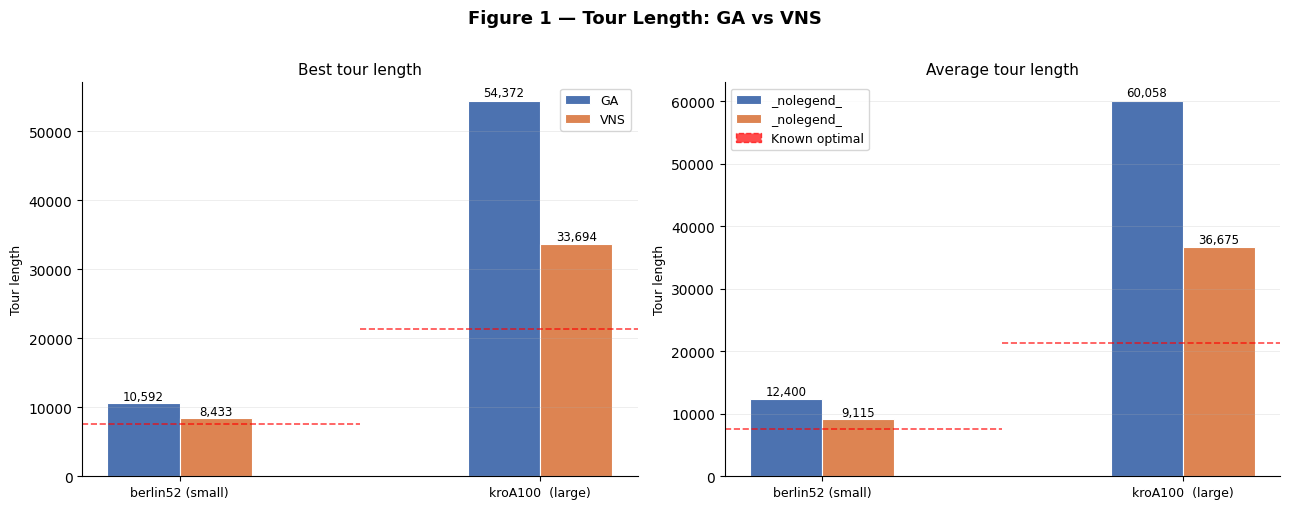

Saved: fig1_tour_length_bar.png



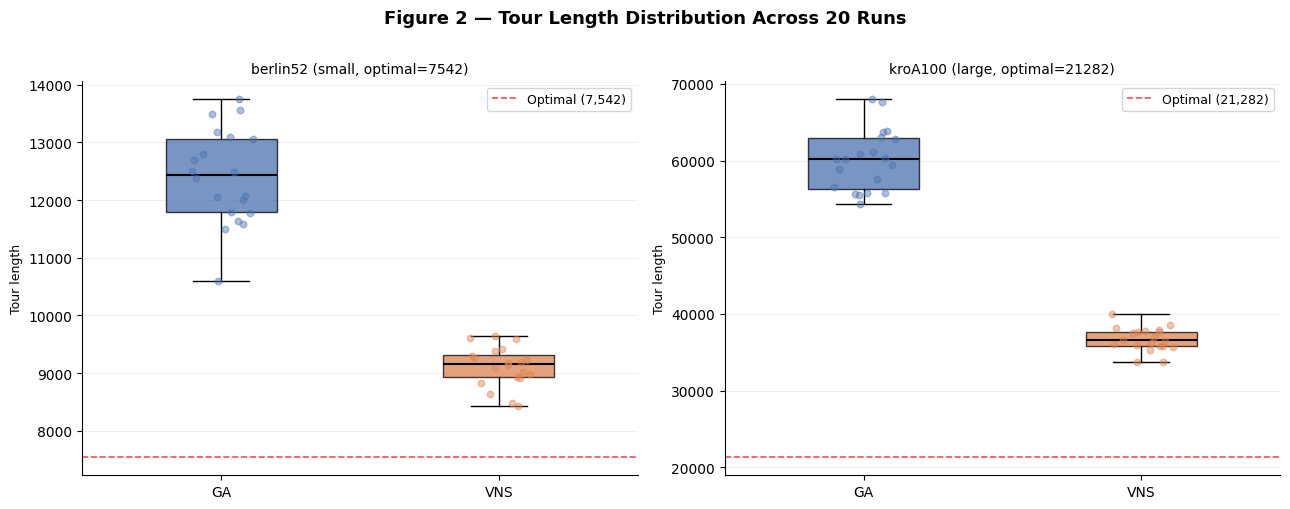

Saved: fig2_boxplots.png



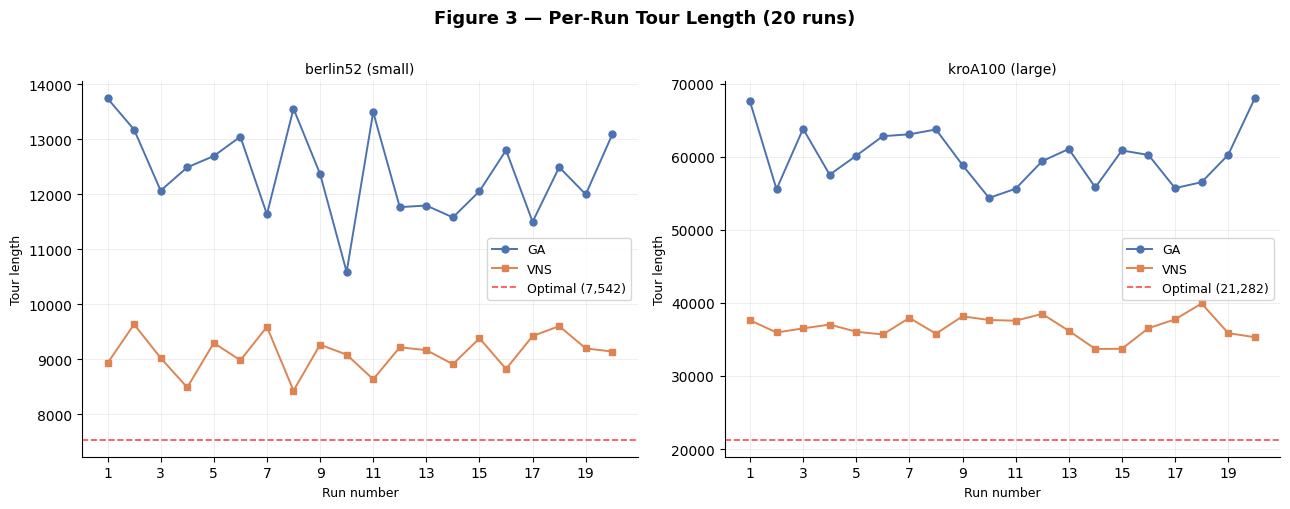

Saved: fig3_per_run.png



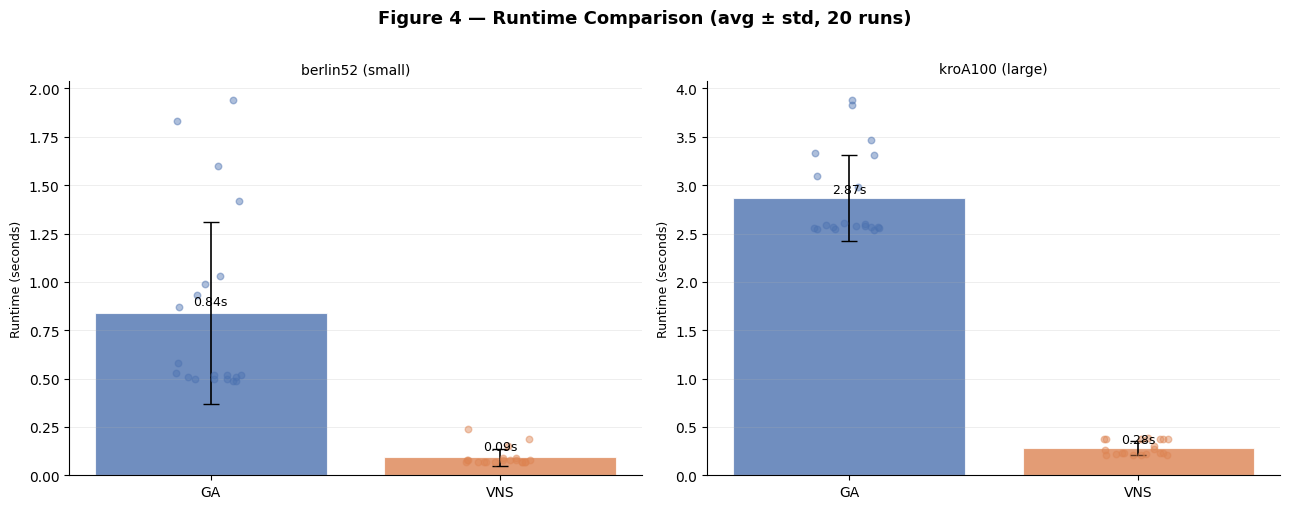

Saved: fig4_runtime.png

   TABLE 1 — Solution Quality: GA vs VNS
Instance Algorithm     Best  Average    Worst  Std Dev  Optimal Gap (%)
berlin52        GA 10592.05 12399.93 13745.96   814.48     7542  40.44%
berlin52       VNS  8432.81  9114.51  9638.79   344.62     7542  11.81%
 kroA100        GA 54372.11 60057.63 67997.18  3945.67    21282 155.48%
 kroA100       VNS 33693.76 36674.58 39920.89  1534.91    21282  58.32%

   TABLE 2 — Compute Efficiency: GA vs VNS
Instance Algorithm  Avg Runtime (s)
berlin52        GA             0.84
berlin52       VNS             0.09
 kroA100        GA             2.87
 kroA100       VNS             0.28



In [ ]:
# ================================================================
# COMPARISON SECTION — GA vs VNS
# ================================================================


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ----------------------------------------------------------------
# Known optimal values
# ----------------------------------------------------------------
OPT_SMALL = 7542    # berlin52
OPT_LARGE = 21282   # kroA100

# ----------------------------------------------------------------
#  build a one-row summary dict from a results DataFrame
# ----------------------------------------------------------------
def summarise(df, optimal):
    tl = df['Tour Length']
    rt = df['Runtime (s)']
    best = tl.min()
    return {
        'Best'        : round(best, 2),
        'Worst'       : round(tl.max(), 2),
        'Average'     : round(tl.mean(), 2),
        'Std Dev'     : round(tl.std(), 2),
        'Known Optimal': optimal,
        'Gap (%)'     : round((best - optimal) / optimal * 100, 2),
        'Avg Runtime (s)': round(rt.mean(), 2),
    }

# ================================================================
# 1. COMBINED SUMMARY TABLE
# ================================================================
rows = {
    ('berlin52 (small)', 'GA' ): summarise(df_ga_small,  OPT_SMALL),
    ('berlin52 (small)', 'VNS'): summarise(df_vns_small, OPT_SMALL),
    ('kroA100  (large)', 'GA' ): summarise(df_ga_large,  OPT_LARGE),
    ('kroA100  (large)', 'VNS'): summarise(df_vns_large, OPT_LARGE),
}

df_summary = pd.DataFrame(rows).T
df_summary.index.names = ['Instance', 'Algorithm']

print('\n' + '='*70)
print('   COMPARISON SUMMARY — GA vs VNS (20 runs each)')
print('='*70)
print(df_summary.to_string())
print('='*70 + '\n')

# ================================================================
# 2. FIGURE 1 — Best & Average tour length (bar chart)
# ================================================================
metrics  = ['Best', 'Average']
instances = ['berlin52 (small)', 'kroA100  (large)']
ga_data  = [[rows[('berlin52 (small)', 'GA')][m],
             rows[('kroA100  (large)', 'GA')][m]]  for m in metrics]
vns_data = [[rows[('berlin52 (small)', 'VNS')][m],
             rows[('kroA100  (large)', 'VNS')][m]] for m in metrics]

x      = np.arange(len(instances))
width  = 0.20
colors = {'GA': ('#4C72B0', '#7EB5DA'), 'VNS': ('#DD8452', '#F5BB8A')}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 — Tour Length: GA vs VNS', fontsize=13, fontweight='bold', y=1.01)

for ax, metric, ga_vals, vns_vals in zip(
        axes, metrics, ga_data, vns_data):

    b1 = ax.bar(x - width/2, ga_vals,  width, label='GA',
                color=colors['GA'][0],  edgecolor='white', linewidth=0.8)
    b2 = ax.bar(x + width/2, vns_vals, width, label='VNS',
                color=colors['VNS'][0], edgecolor='white', linewidth=0.8)

    # Annotate bars with values
    for bar in [*b1, *b2]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.005,
                f'{h:,.0f}', ha='center', va='bottom', fontsize=8.5)

    # Draw optimal reference lines
    for opt, inst in zip([OPT_SMALL, OPT_LARGE], x):
        ax.axhline(opt, xmin=(inst)/len(instances),
                   xmax=(inst+1)/len(instances),
                   color='red', linewidth=1.2, linestyle='--', alpha=0.7)

    ax.set_title(f'{metric} tour length', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(instances, fontsize=9)
    ax.set_ylabel('Tour length', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

# Add red dashed legend entry
red_patch = mpatches.Patch(color='red', linestyle='--',
                           label='Known optimal', alpha=0.7)
axes[1].legend(handles=[*axes[1].get_legend().legend_handles, red_patch],
               fontsize=9)

plt.tight_layout()
plt.savefig('fig1_tour_length_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_tour_length_bar.png\n')

# ================================================================
# 3. FIGURE 2 — Box plots (distribution across 20 runs)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 — Tour Length Distribution Across 20 Runs',
             fontsize=13, fontweight='bold', y=1.01)

for ax, inst_label, df_ga, df_vns, optimal in zip(
        axes,
        ['berlin52 (small, optimal=7542)', 'kroA100 (large, optimal=21282)'],
        [df_ga_small, df_ga_large],
        [df_vns_small, df_vns_large],
        [OPT_SMALL, OPT_LARGE]):

    data = [df_ga['Tour Length'].values, df_vns['Tour Length'].values]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.4,
                      medianprops=dict(color='black', linewidth=1.5))

    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][1].set_alpha(0.75)

    # Overlay individual run points (jittered)
    for i, (vals, col) in enumerate(
            zip(data, ['#4C72B0', '#DD8452']), start=1):
        jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=col, alpha=0.45, s=22, zorder=3)

    # Known optimal line
    ax.axhline(optimal, color='red', linewidth=1.2,
               linestyle='--', alpha=0.7, label=f'Optimal ({optimal:,})')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['GA', 'VNS'], fontsize=10)
    ax.set_title(inst_label, fontsize=10)
    ax.set_ylabel('Tour length', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_boxplots.png\n')

# ================================================================
# 4. FIGURE 3 — Per-run tour length across 20 runs (line plot)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 — Per-Run Tour Length (20 runs)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, inst_label, df_ga, df_vns, optimal in zip(
        axes,
        ['berlin52 (small)', 'kroA100 (large)'],
        [df_ga_small, df_ga_large],
        [df_vns_small, df_vns_large],
        [OPT_SMALL, OPT_LARGE]):

    runs = df_ga['Run'].values

    ax.plot(runs, df_ga['Tour Length'],
            marker='o', markersize=5, linewidth=1.4,
            color='#4C72B0', label='GA')
    ax.plot(runs, df_vns['Tour Length'],
            marker='s', markersize=5, linewidth=1.4,
            color='#DD8452', label='VNS')
    ax.axhline(optimal, color='red', linewidth=1.2,
               linestyle='--', alpha=0.7, label=f'Optimal ({optimal:,})')

    ax.set_title(inst_label, fontsize=10)
    ax.set_xlabel('Run number', fontsize=9)
    ax.set_ylabel('Tour length', fontsize=9)
    ax.set_xticks(runs[::2])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_per_run.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_per_run.png\n')

# ================================================================
# 5. FIGURE 4 — Runtime comparison (bar + individual points)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4 — Runtime Comparison (avg ± std, 20 runs)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, inst_label, df_ga, df_vns in zip(
        axes,
        ['berlin52 (small)', 'kroA100 (large)'],
        [df_ga_small, df_ga_large],
        [df_vns_small, df_vns_large]):

    ga_rt  = df_ga['Runtime (s)'].values
    vns_rt = df_vns['Runtime (s)'].values
    means  = [ga_rt.mean(), vns_rt.mean()]
    stds   = [ga_rt.std(),  vns_rt.std()]
    colors_rt = ['#4C72B0', '#DD8452']

    bars = ax.bar([1, 2], means, yerr=stds, capsize=6,
                  color=colors_rt, alpha=0.8, edgecolor='white',
                  linewidth=0.8, error_kw=dict(elinewidth=1.2))

    # Overlay individual run runtimes
    for i, (vals, col) in enumerate(
            zip([ga_rt, vns_rt], colors_rt), start=1):
        jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=col, alpha=0.45, s=22, zorder=3)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(stds)*0.05,
                f'{mean:.2f}s', ha='center', va='bottom', fontsize=9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['GA', 'VNS'], fontsize=10)
    ax.set_title(inst_label, fontsize=10)
    ax.set_ylabel('Runtime (seconds)', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_runtime.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_runtime.png\n')

# ================================================================
# 6. FINAL FORMATTED COMPARISON TABLE
# ================================================================
print('='*80)
print('   TABLE 1 — Solution Quality: GA vs VNS')
print('='*80)

tbl_rows = []
for inst_key, opt, label in [
        ('berlin52 (small)', OPT_SMALL, 'berlin52'),
        ('kroA100  (large)', OPT_LARGE, 'kroA100')]:
    for algo in ['GA', 'VNS']:
        s = rows[(inst_key, algo)]
        tbl_rows.append({
            'Instance' : label,
            'Algorithm': algo,
            'Best'     : s['Best'],
            'Average'  : s['Average'],
            'Worst'    : s['Worst'],
            'Std Dev'  : s['Std Dev'],
            'Optimal'  : s['Known Optimal'],
            'Gap (%)'  : f"{s['Gap (%)']}%",
        })

df_tbl = pd.DataFrame(tbl_rows)
print(df_tbl.to_string(index=False))

print('\n' + '='*80)
print('   TABLE 2 — Compute Efficiency: GA vs VNS')
print('='*80)

eff_rows = []
for inst_key, label in [
        ('berlin52 (small)', 'berlin52'),
        ('kroA100  (large)', 'kroA100')]:
    for algo in ['GA', 'VNS']:
        s = rows[(inst_key, algo)]
        eff_rows.append({
            'Instance'      : label,
            'Algorithm'     : algo,
            'Avg Runtime (s)': s['Avg Runtime (s)'],
        })

df_eff = pd.DataFrame(eff_rows)
print(df_eff.to_string(index=False))
print('='*80 + '\n')